In [6]:
import os
import cv2
import pandas as pd
from decord import VideoReader, cpu
from tqdm import tqdm

# Define input and output directory paths
RAW_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\raw\nexar_collision_prediction\train"
OUTPUT_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames"

# Create target directories for train and validation splits
for split in ['train', 'val']:
    for cls in ['accident', 'no_accident']:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# Define paths for both positive and negative metadata CSV files
pos_meta_file = os.path.join(RAW_DATA_DIR, "positive", "metadata.csv")
neg_meta_file = os.path.join(RAW_DATA_DIR, "negative", "metadata.csv")

# Validate the existence of both metadata files
if not os.path.exists(pos_meta_file) or not os.path.exists(neg_meta_file):
    raise FileNotFoundError("One or both metadata.csv files are missing in positive/negative folders. Please verify.")

print("Loading and merging dataset metadata...")

# Read both CSV files into pandas DataFrames
df_pos = pd.read_csv(pos_meta_file)
df_neg = pd.read_csv(neg_meta_file)

# Concatenate them into a single unified DataFrame
df_metadata = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"Total videos identified across both classes: {len(df_metadata)}")

FRAMES_PER_SECOND_TO_EXTRACT = 2
metadata_records = []

print("Starting temporal frame extraction pipeline...")

# Process each video based on unified metadata attributes
for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata)):
    vid_filename = row['file_name']
    label = row.get('label', 1 if 'time_of_event' in row and pd.notna(row['time_of_event']) else 0)
    time_of_event = row.get('time_of_event', None)
    
    # Determine the source folder based on the class label
    folder_name = 'positive' if label == 1 else 'negative'
    vid_path = os.path.join(RAW_DATA_DIR, folder_name, vid_filename)
    
    if not os.path.exists(vid_path):
        continue

    try:
        # Initialize Decord VideoReader for optimized CPU decoding
        video_reader = VideoReader(vid_path, ctx=cpu(0))
        fps = video_reader.get_avg_fps()
        total_frames = len(video_reader)
        total_duration = total_frames / fps
        
        # Apply temporal trimming based on the event timestamp
        if label == 1 and pd.notna(time_of_event):
            # For positive samples: Extract window [3s before event to 1s after event]
            start_time = max(0, time_of_event - 3.0)
            end_time = min(total_duration, time_of_event + 1.0)
            class_name = 'accident'
        else:
            # For negative samples: Extract a 4-second continuous clip from the center
            mid_time = total_duration / 2
            start_time = max(0, mid_time - 2.0)
            end_time = min(total_duration, mid_time + 2.0)
            class_name = 'no_accident'
            
        start_frame = int(start_time * fps)
        end_frame = int(end_time * fps)
        
        step = int(fps / FRAMES_PER_SECOND_TO_EXTRACT)
        if step == 0: 
            step = 1
        
        # Generate the list of target frame indices
        target_frame_indices = list(range(start_frame, end_frame, step))
        
        if target_frame_indices:
            # Retrieve the batch of frames in a single operation
            frames_array = video_reader.get_batch(target_frame_indices).asnumpy()
            
            # Apply 80/20 train-validation split, grouping by video ID
            split_name = 'train' if idx % 5 != 0 else 'val'
            save_dir = os.path.join(OUTPUT_DIR, split_name, class_name)
            
            for i, frame_rgb in enumerate(frames_array):
                # Convert color space from RGB to BGR for OpenCV compatibility
                frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
                frame_resized = cv2.resize(frame_bgr, (224, 224))
                
                frame_name = f"video_{idx}_f{target_frame_indices[i]}.jpg"
                out_path = os.path.join(save_dir, frame_name)
                cv2.imwrite(out_path, frame_resized)
                
                # Log extracted frame metadata for subsequent analysis
                metadata_records.append({
                    'video_id': idx,
                    'frame_name': frame_name,
                    'label': label,
                    'split': split_name,
                    'weather': row.get('weather', 'Unknown'),
                    'scene': row.get('scene', 'Unknown'),
                    'light_conditions': row.get('light_conditions', 'Unknown'),
                    'is_event_frame': (label == 1 and pd.notna(time_of_event) and abs((target_frame_indices[i]/fps) - time_of_event) <= 0.5)
                })
    except Exception as e:
        print(f"Failed to process video {vid_filename}: {e}")
        continue

# Export the consolidated metadata to CSV
df_meta_clean = pd.DataFrame(metadata_records)
df_meta_clean.to_csv(os.path.join(OUTPUT_DIR, 'extracted_frames_metadata.csv'), index=False)
print("\nFrame extraction pipeline completed successfully.")

Loading and merging dataset metadata...
Total videos identified across both classes: 1500
Starting temporal frame extraction pipeline...


100%|██████████| 1500/1500 [05:48<00:00,  4.30it/s]


Frame extraction pipeline completed successfully.


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Lambda, TimeDistributed, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Define Paths 
PROCESSED_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames"
CSV_PATH = os.path.join(PROCESSED_DATA_DIR, 'extracted_frames_metadata.csv')

BATCH_SIZE = 8  
SEQ_LENGTH = 8  # Number of consecutive frames per video to feed into LSTM
IMG_HEIGHT, IMG_WIDTH = 224, 224

print("Loading metadata for Sequence Generation...")
df_meta = pd.read_csv(CSV_PATH)
train_df = df_meta[df_meta['split'] == 'train']
val_df = df_meta[df_meta['split'] == 'val']

# 2. Build Custom Video Sequence Generator
class VideoFrameGenerator(Sequence):
    def __init__(self, df, img_dir, batch_size, seq_length, img_height, img_width):
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.seq_length = seq_length
        self.img_height = img_height
        self.img_width = img_width
        self.video_ids = self.df['video_id'].unique()

    def __len__(self):
        return int(np.floor(len(self.video_ids) / self.batch_size))

    def __getitem__(self, index):
        # Select a batch of video IDs
        batch_vids = self.video_ids[index * self.batch_size:(index + 1) * self.batch_size]
        
        # X shape: (Batch, TimeSteps, Height, Width, Channels)
        X = np.empty((self.batch_size, self.seq_length, self.img_height, self.img_width, 3), dtype=np.float32)
        y = np.empty((self.batch_size), dtype=int)

        for i, vid in enumerate(batch_vids):
            vid_df = self.df[self.df['video_id'] == vid].sort_values(by='frame_name')
            frames = vid_df['frame_name'].tolist()
            label = vid_df['label'].values[0]
            split_folder = vid_df['split'].values[0]
            cls_folder = 'accident' if label == 1 else 'no_accident'

            # Pad or truncate frames to match EXACTLY seq_length
            if len(frames) < self.seq_length:
                frames += [frames[-1]] * (self.seq_length - len(frames))
            else:
                frames = frames[:self.seq_length]

            for j, frame_name in enumerate(frames):
                img_path = os.path.join(self.img_dir, split_folder, cls_folder, frame_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0  # Rescale to 0-1
                    X[i, j,] = img

            y[i] = label

        return X, y

print("Initializing Spatio-Temporal Data Generators...")
train_generator = VideoFrameGenerator(train_df, PROCESSED_DATA_DIR, BATCH_SIZE, SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH)
val_generator = VideoFrameGenerator(val_df, PROCESSED_DATA_DIR, BATCH_SIZE, SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH)

# 3. Define ROI Masking
def roi_mask(x):
    mask = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    mask[:int(IMG_HEIGHT * 0.3), :, :] = 0 
    mask_tensor = tf.constant(mask, dtype=tf.float32)
    return x * mask_tensor

print("Building CNN+LSTM Model Architecture...")

# 4. Construct the Spatio-Temporal Architecture
# the shape includes SEQ_LENGTH as the temporal dimension
inputs = Input(shape=(SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3))

# Apply mask to EACH frame in the sequence using TimeDistributed
x = TimeDistributed(Lambda(roi_mask, name="roi_mask_layer"))(inputs) 

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), 
    include_top=False, 
    weights='imagenet'
)
# Freeze the base model strictly as advised by the mentor
base_model.trainable = False

# Pass the sequence of frames through the CNN
x = TimeDistributed(base_model, name="td_mobilenetv2")(x, training=False)
x = TimeDistributed(GlobalAveragePooling2D(), name="td_global_avg_pooling")(x)

# 5. Inject LSTM to learn temporal dynamics across frames
x = LSTM(128, return_sequences=False, name="lstm_temporal_encoder")(x)
x = Dropout(0.5, name="dropout_regularization")(x)

outputs = Dense(1, activation='sigmoid', name="binary_classifier")(x)

model = Model(inputs, outputs, name="Nexar_Collision_Predictor_V3_LSTM")

# 6. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Loading metadata for Sequence Generation...
Initializing Spatio-Temporal Data Generators...
Building CNN+LSTM Model Architecture...



Model: "Nexar_Collision_Predictor_V3_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 224, 224, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8, 224, 224, 3) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_mobilenetv2                  │ (None, 8, 7, 7, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_global_avg_pooling           │ (None, 8, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_temporal_encoder (LSTM)    │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,521 (11.37 MB)

 Trainable params: 721,537 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [2]:
# Define MLOps Callbacks
MODEL_SAVE_PATH = "v3_lstm_best_accident_model.keras"

callbacks_list = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("Starting Spatio-Temporal model training...")

# train model
EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list
)

print("\nTraining completed successfully!")

Starting Spatio-Temporal model training...


c:\Users\M.Ali\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.6483 - auc: 0.6869 - loss: 0.6579
Epoch 1: val_auc improved from None to 0.74543, saving model to v3_lstm_best_accident_model.keras

Epoch 1: finished saving model to v3_lstm_best_accident_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 150s 908ms/step - accuracy: 0.6483 - auc: 0.6869 - loss: 0.6579 - val_accuracy: 0.5169 - val_auc: 0.7454 - val_loss: 0.8522 - learning_rate: 0.0010
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6567 - auc: 0.7066 - loss: 0.6230
Epoch 2: val_auc improved from 0.74543 to 0.78420, saving model to v3_lstm_best_accident_model.keras

Epoch 2: finished saving model to v3_lstm_best_accident_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 430ms/step - accuracy: 0.6567 - auc: 0.7066 - loss: 0.6230 - val_accuracy: 0.5811 - val_auc: 0.7842 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6342 - auc: 0.6812 - loss: 0.6588
Epoc

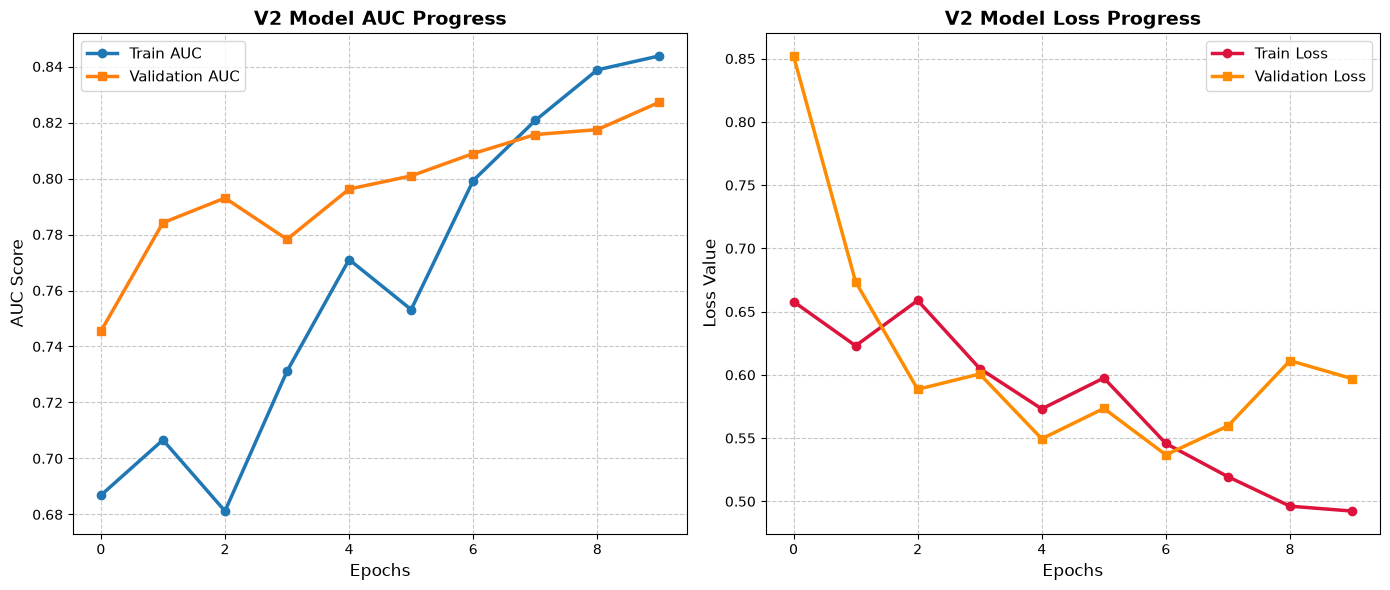

Training performance charts successfully generated and saved as 'v2_training_performance.png'.


In [ ]:
import matplotlib.pyplot as plt

# Set the overall figure size
plt.figure(figsize=(14, 6))

# 1. Plot AUC Metric (Training vs Validation)
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC', linewidth=2.5, marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', linewidth=2.5, marker='s')
plt.title('V2 Model AUC Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Plot Loss Metric (Training vs Validation)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5, marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', color='darkorange')
plt.title('V2 Model Loss Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.savefig('v2_training_performance.png', dpi=300)
plt.show()

print("Training performance charts successfully generated and saved as 'v2_training_performance.png'.")

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from decord import VideoReader, cpu
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

print("Initiating Test Set Evaluation...")

# 1. Absolute Paths Setup
BASE_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP"
TEST_PUB_DIR = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "test-public")
TEST_PRIV_DIR = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "test-private")
SOLUTION_CSV_PATH = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "solution.csv")

MODEL_PATH = "v3_lstm_best_accident_model.keras"  

SEQ_LENGTH = 8
IMG_HEIGHT, IMG_WIDTH = 224, 224

# 2. Load Model Architecture
def roi_mask(x):
    mask = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    mask[:int(IMG_HEIGHT * 0.3), :, :] = 0 
    mask_tensor = tf.constant(mask, dtype=tf.float32)
    return x * mask_tensor

print("Loading V3 LSTM Model...")
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'roi_mask': roi_mask})

# 3. Index Test Videos
print("Indexing video paths...")
video_paths = {}
for test_dir in [TEST_PUB_DIR, TEST_PRIV_DIR]:
    for cls in ['positive', 'negative']:
        cls_dir = os.path.join(test_dir, cls)
        if os.path.exists(cls_dir):
            for f in os.listdir(cls_dir):
                if f.endswith('.mp4') or f.endswith('.mkv'):
                    video_paths[f] = os.path.join(cls_dir, f)
                    video_paths[os.path.splitext(f)[0]] = os.path.join(cls_dir, f)

# 4. On-the-fly Video Processor
def process_video_for_eval(vid_path):
    try:
        vr = VideoReader(vid_path, ctx=cpu(0))
        total_frames = len(vr)
        indices = np.linspace(0, total_frames - 1, SEQ_LENGTH, dtype=int)
        frames = vr.get_batch(indices).asnumpy()
        
        X = np.empty((SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
        for i, frame in enumerate(frames):
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            frame_resized = cv2.resize(frame_bgr, (IMG_WIDTH, IMG_HEIGHT))
            frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB) / 255.0
            X[i,] = frame_rgb
            
        return np.expand_dims(X, axis=0)
    except Exception:
        return None

# 5. Native Evaluation Loop
print("Evaluating Model on Test Data...")
solution_df = pd.read_csv(SOLUTION_CSV_PATH)

y_true = []
y_pred_probs = []

for idx, row in tqdm(solution_df.iterrows(), total=len(solution_df), desc="Analyzing"):
    vid_id_raw = int(row['id'])
    vid_id = f"{vid_id_raw:05d}"
    target = row['target']  # True label (1 or 0)
    
    vid_path = video_paths.get(vid_id) or video_paths.get(f"{vid_id}.mp4")
    
    if vid_path and os.path.exists(vid_path):
        X_input = process_video_for_eval(vid_path)
        if X_input is not None:
            # Get Probability
            prob = model.predict(X_input, verbose=0)[0][0]
            
            y_true.append(target)
            y_pred_probs.append(prob)

# 6. Calculate Standard Metrics
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
# Apply 0.5 threshold to convert probabilities to absolute classes (0 or 1)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# Equivalent to Keras validation metrics
test_loss = log_loss(y_true, y_pred_probs)
test_acc = accuracy_score(y_true, y_pred_classes)
test_auc = roc_auc_score(y_true, y_pred_probs)

print("\n")
print("==================================================")
print("TEST SET PERFORMANCE V3:")
print("==================================================")
print(f" Test Loss : {test_loss:.4f}")
print(f" Test Accuracy                   : {test_acc:.4f} ({(test_acc*100):.2f}%)")
print(f" Test AUC (ROC)                  : {test_auc:.4f}")
print("==================================================")

Initiating Test Set Evaluation...
Loading V3 LSTM Model...
Indexing video paths...
Evaluating Model on Test Data...


Analyzing: 100%|██████████| 1344/1344 [06:36<00:00,  3.39it/s]



TEST SET PERFORMANCE V3:
 Test Loss : 0.6724
 Test Accuracy                   : 0.6473 (64.73%)
 Test AUC (ROC)                  : 0.7280
